# 🧹 Credit Risk — EDA

## 📌 Project Overview

## 📚 Libraries

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import dcor
from sklearn.utils import resample
warnings.filterwarnings("ignore")

## 📂 Load Dataset

In [55]:
path = Path("Data")
df_clean = pd.read_csv(path / "german_credit_cleaned.csv")

## 🎯 Correlation Analysis

Understanding the relationships between variables is a key step in credit risk modeling, as it helps identify the factors most associated with default behavior and potential dependencies between predictors.  

In this section, both **linear** and **non-linear** correlation techniques are explored to obtain a more complete view of the dataset structure. Traditional Pearson correlations are used to capture linear relationships, while Distance Correlation is applied to detect more complex and non-linear interactions that may not be visible through standard correlation methods alone.  

This combined approach provides deeper insight into variable behavior, feature relevance, and hidden patterns that could improve predictive modeling performance.

### Linear Correlations

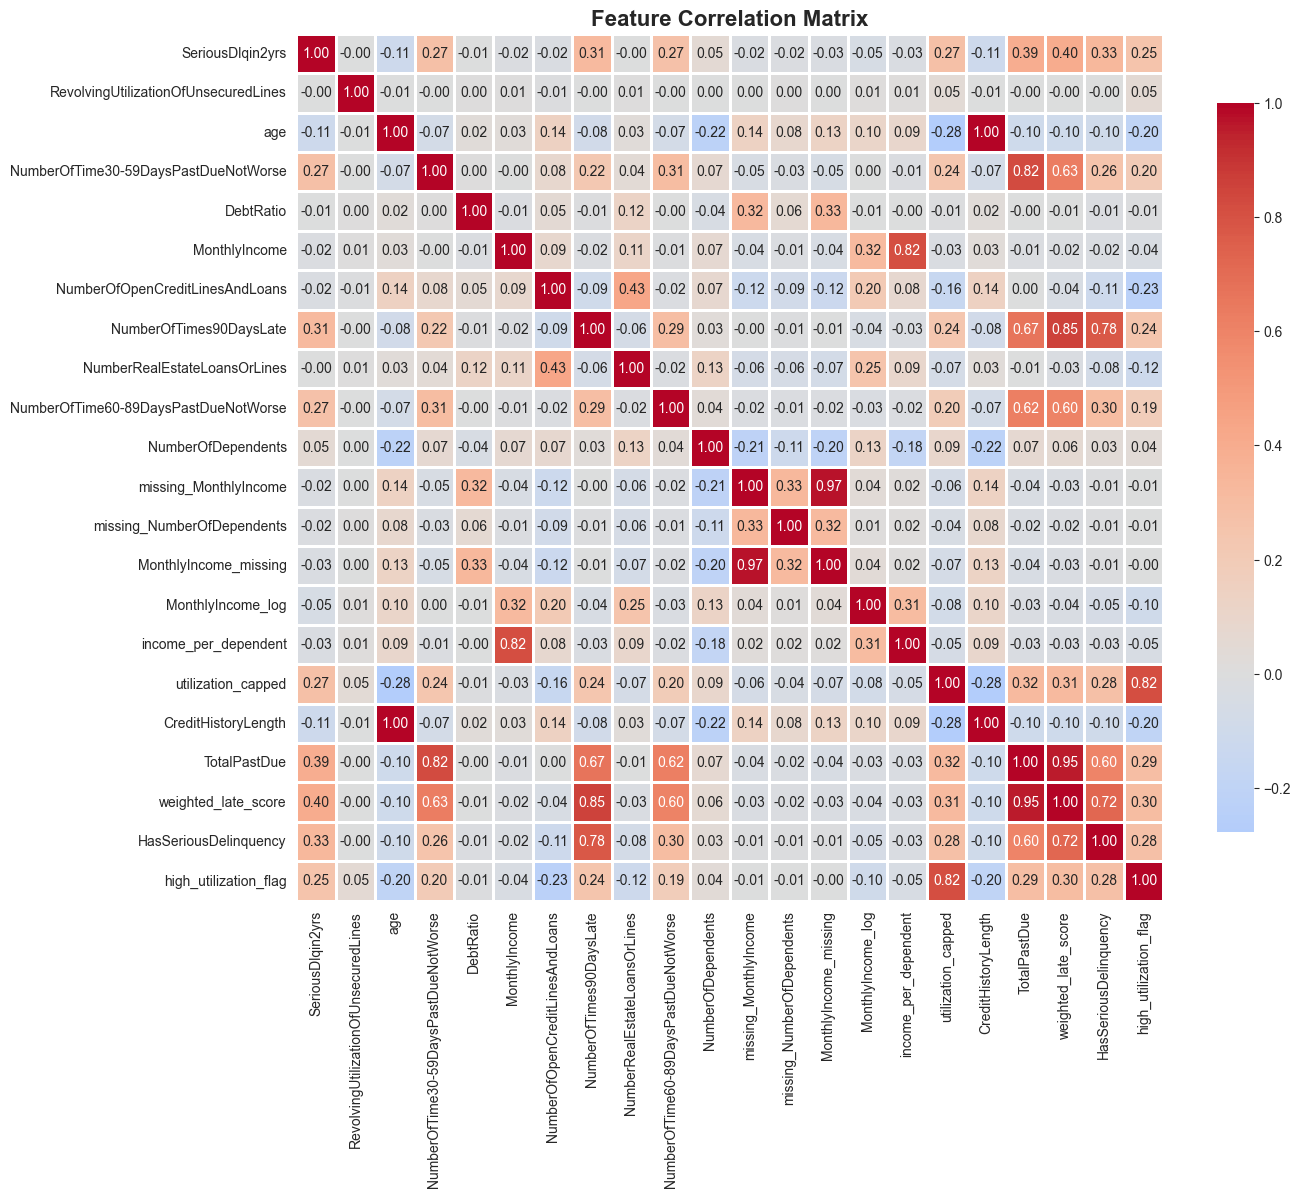


🎯 Top Correlations with Default:
weighted_late_score                     0.398456
TotalPastDue                            0.392663
HasSeriousDelinquency                   0.332751
NumberOfTimes90DaysLate                 0.314552
NumberOfTime30-59DaysPastDueNotWorse    0.274503
utilization_capped                      0.274240
NumberOfTime60-89DaysPastDueNotWorse    0.268144
high_utilization_flag                   0.253828
NumberOfDependents                      0.048328
RevolvingUtilizationOfUnsecuredLines   -0.001744
Name: SeriousDlqin2yrs, dtype: float64


In [56]:
# Correlation Analysis
fig, ax = plt.subplots(figsize=(14, 12))

# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations with target
target_corr = correlation_matrix['SeriousDlqin2yrs'].sort_values(ascending=False)
print("\n🎯 Top Correlations with Default:")
print(target_corr[1:11])  # Exclude target itself

The correlation analysis shows that delinquency-related variables are the strongest predictors of default behavior. Features such as `weighted_late_score`, `TotalPastDue`, and `HasSeriousDelinquency` present the highest positive correlations with the target, highlighting the importance of previous repayment issues in identifying high-risk borrowers. Past-due frequency variables (`30-59`, `60-89`, and `90+ days late`) also exhibit strong relationships with default, reinforcing the predictive value of historical payment behavior. In contrast, demographic and general financial variables such as `NumberOfDependents` or `RevolvingUtilizationOfUnsecuredLines` show relatively weak linear correlations, suggesting that their impact may be more indirect or non-linear.

### Non-Linear Correlations

To better understand the factors associated with credit default risk, we complement this analysis with **Distance Correlation (dCor)**, a more flexible metric capable of detecting both linear and non-linear dependencies. Unlike Pearson correlation, distance correlation values range from 0 to 1, where values closer to 1 indicate a stronger statistical dependence between variables.

This combined approach provides a more complete view of how different financial and behavioral features relate to default risk.

In [57]:
import dcor
target_dcor = {}
for col in numeric_cols:
    if col != 'SeriousDlqin2yrs':
        target_dcor[col] = dcor.distance_correlation(df_clean[col], df_clean['SeriousDlqin2yrs'])
target_dcor_series = pd.Series(target_dcor).sort_values(ascending=False)
print("\n🎯 Top Distance Correlations with Default:")
print(target_dcor_series.head(10))


🎯 Top Distance Correlations with Default:
weighted_late_score                     0.402988
TotalPastDue                            0.379070
NumberOfTimes90DaysLate                 0.342344
HasSeriousDelinquency                   0.332751
NumberOfTime60-89DaysPastDueNotWorse    0.272937
utilization_capped                      0.269371
NumberOfTime30-59DaysPastDueNotWorse    0.265137
high_utilization_flag                   0.253828
age                                     0.111711
CreditHistoryLength                     0.111711
dtype: float64


The non-linear correlation analysis confirms that delinquency-related variables remain the most influential factors associated with default risk. Features such as `weighted_late_score`, `TotalPastDue`, and `NumberOfTimes90DaysLate` show the strongest distance correlations, indicating that their relationship with default extends beyond simple linear patterns. Additionally, variables like `age` and `CreditHistoryLength`, which exhibited weak linear correlations, show higher non-linear associations, suggesting that their effect on credit risk may depend on more complex behavioral trends rather than direct proportional relationships. These results highlight the value of incorporating non-linear analysis in credit risk modeling, especially for capturing hidden dependencies between borrower characteristics and default probability.

## 🔎 EDA: Likehood of default

Under this section, the analysis focuses on understanding how the likelihood of default changes across different customer groups and financial profiles. The study includes the estimation of the mean default rate together with both parametric (95% normal confidence intervals) and non-parametric (bootstrap confidence intervals) uncertainty estimates, providing a more robust view of risk behavior. In addition, differences between key segments — such as age ranges, income levels, delinquency history, and credit exposure — are explored to identify patterns associated with higher default probability. To complement the visual analysis, statistical techniques including Levene’s test and Cliff’s Delta are applied to evaluate variance differences and effect sizes between groups, helping distinguish statistically meaningful relationships from purely descriptive patterns.

In [58]:
default_rate = df_clean['SeriousDlqin2yrs'].mean()
print(f"Default Rate (Mean): {default_rate:.4f}")

Default Rate (Mean): 0.0660


### Confidence intervals for the default rate

To quantify the uncertainty around the estimated default rate, we compute a 95% confidence interval using the Wilson method, which provides better performance than the normal approximation, especially for proportions close to 0 or 1 or when class imbalance is present. This interval gives a statistically robust range for the true population default rate based on the observed sample.

In addition to the analytical approach, we also estimate confidence intervals using bootstrap resampling. This method repeatedly samples from the dataset with replacement and recalculates the default rate, allowing us to empirically approximate its sampling distribution. The resulting interval does not rely on strong parametric assumptions and is therefore particularly useful for validating the robustness of the analytical estimate.

Together, both approaches provide complementary perspectives: the Wilson interval offers a closed-form statistical estimate, while bootstrap methods provide a data-driven, assumption-light validation of uncertainty.

In [59]:
import statsmodels.api as sm
# Calculate confidence interval for the default rate
conf_int = sm.stats.proportion_confint(count=df_clean['SeriousDlqin2yrs'].sum(), 
                                        nobs=len(df_clean), 
                                        alpha=0.05, 
                                        method='wilson')
print(f"95% Confidence Interval for Default Rate: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")

95% Confidence Interval for Default Rate: [0.0647, 0.0672]


In [60]:
# Bootstrap confidence interval for default rate
def calculate_default_rate(data, target_col="SeriousDlqin2yrs"):
    """
    Calculate default rate.

    Parameters:
        data (pd.DataFrame): Input dataset
        target_col (str): Target column name

    Returns:
        float: Mean default rate
    """
    return data[target_col].mean()


def bootstrap_default_rates(
    df,
    target_col="SeriousDlqin2yrs",
    n_iterations=1000
):
    """
    Generate bootstrap samples for default rate estimation.

    Parameters:
        df (pd.DataFrame): Input dataset
        target_col (str): Target column name
        n_iterations (int): Number of bootstrap iterations

    Returns:
        list: Bootstrap default rates
    """

    bootstrap_rates = []

    for i in range(n_iterations):
        sample = resample(
            df,
            replace=True,
            n_samples=len(df),
            random_state=i
        )

        rate = calculate_default_rate(sample, target_col)
        bootstrap_rates.append(rate)

    return bootstrap_rates


def compute_confidence_interval(
    bootstrap_rates,
    confidence_level=95
):
    """
    Compute confidence interval from bootstrap samples.

    Parameters:
        bootstrap_rates (list): Bootstrap sample statistics
        confidence_level (int): Confidence level percentage

    Returns:
        tuple: Lower and upper confidence bounds
    """

    alpha = 100 - confidence_level

    lower_bound = np.percentile(
        bootstrap_rates,
        alpha / 2
    )

    upper_bound = np.percentile(
        bootstrap_rates,
        100 - (alpha / 2)
    )

    return lower_bound, upper_bound


def plot_bootstrap_distribution(
    bootstrap_rates,
    lower_bound,
    upper_bound
):
    """
    Plot bootstrap distribution with confidence interval.

    Parameters:
        bootstrap_rates (list): Bootstrap sample statistics
        lower_bound (float): Lower CI bound
        upper_bound (float): Upper CI bound
    """

    sns.set_style("white")

    plt.figure(figsize=(10, 5))

    sns.histplot(
        bootstrap_rates,
        bins=30,
        kde=True,
        edgecolor="black"
    )

    plt.axvline(
        lower_bound,
        linestyle="--",
        linewidth=2,
        label=f"Lower Bound ({lower_bound:.4f})"
    )

    plt.axvline(
        upper_bound,
        linestyle="--",
        linewidth=2,
        label=f"Upper Bound ({upper_bound:.4f})"
    )

    plt.title(
        "Bootstrap Distribution of Default Rate",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel(
        "Default Rate",
        fontsize=12,
        fontweight="bold"
    )

    plt.ylabel(
        "Frequency",
        fontsize=12,
        fontweight="bold"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()


def bootstrap_confidence_interval_analysis(
    df,
    target_col="SeriousDlqin2yrs",
    n_iterations=1000
):
    """
    Complete bootstrap confidence interval workflow.

    Parameters:
        df (pd.DataFrame): Input dataset
        target_col (str): Target column name
        n_iterations (int): Number of bootstrap iterations
    """

    bootstrap_rates = bootstrap_default_rates(
        df,
        target_col,
        n_iterations
    )

    lower_bound, upper_bound = compute_confidence_interval(
        bootstrap_rates
    )

    print(
        f"Bootstrap 95% Confidence Interval "
        f"for Default Rate: "
        f"[{lower_bound:.4f}, {upper_bound:.4f}]"
    )

    plot_bootstrap_distribution(
        bootstrap_rates,
        lower_bound,
        upper_bound
    )

Bootstrap 95% Confidence Interval for Default Rate: [0.0647, 0.0674]


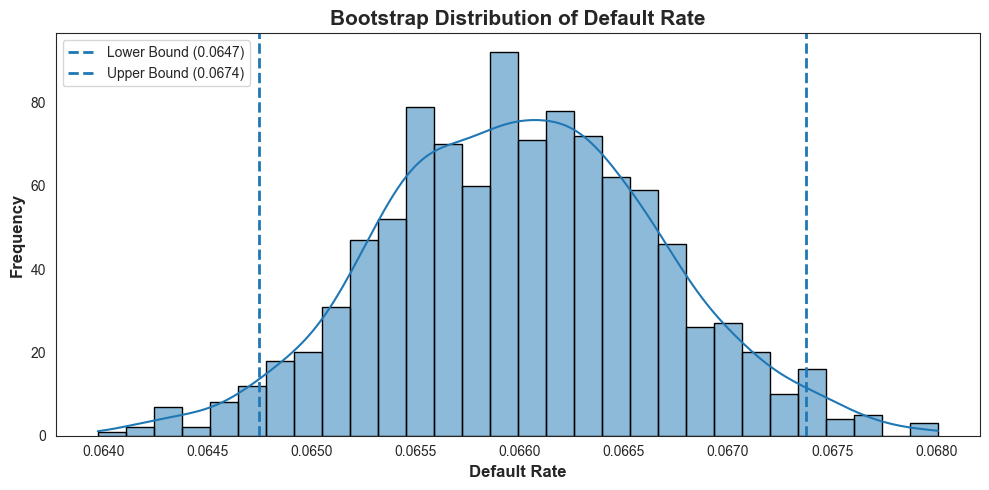

In [61]:
bootstrap_confidence_interval_analysis(df_clean)

The estimated mean default rate in the dataset is **0.0660**, indicating that approximately 6.6% of the observed individuals are classified as defaulters.

To quantify the uncertainty of this estimate, we compute a 95% confidence interval using the Wilson method, obtaining a range of **[0.0647, 0.0672]**. This provides a precise analytical estimate of the true population default rate.

To validate the robustness of this result, we also apply a bootstrap approach, which yields a very similar 95% confidence interval of **[0.0647, 0.0674]**. The close agreement between both intervals reinforces the stability of the estimated default rate and suggests that the result is not sensitive to the underlying assumptions of the analytical method.

Overall, both methods consistently indicate a low and tightly concentrated default rate in the dataset.

##  Feature Distribution by Default Status

This section compares the distribution of key financial and demographic features between clients who defaulted and those who did not. By analyzing both distributional differences and average values across groups, we can identify which variables show meaningful separation between risk profiles and may therefore be useful for predicting credit default behavior.

In [62]:
# Num-Variables
num_var = df_clean[["RevolvingUtilizationOfUnsecuredLines","DebtRatio", "MonthlyIncome", "age", "SeriousDlqin2yrs"]]

# Groupwise mean
groupwise_mean = num_var.groupby('SeriousDlqin2yrs').mean()
print("Groupwise Mean by Default Status:")
print(groupwise_mean)

Groupwise Mean by Default Status:
                  RevolvingUtilizationOfUnsecuredLines   DebtRatio  \
SeriousDlqin2yrs                                                     
0                                             6.173919  357.456638   
1                                             4.417834  299.411254   

                  MonthlyIncome        age  
SeriousDlqin2yrs                            
0                   6561.488219  52.766632  
1                   5508.198122  46.050618  


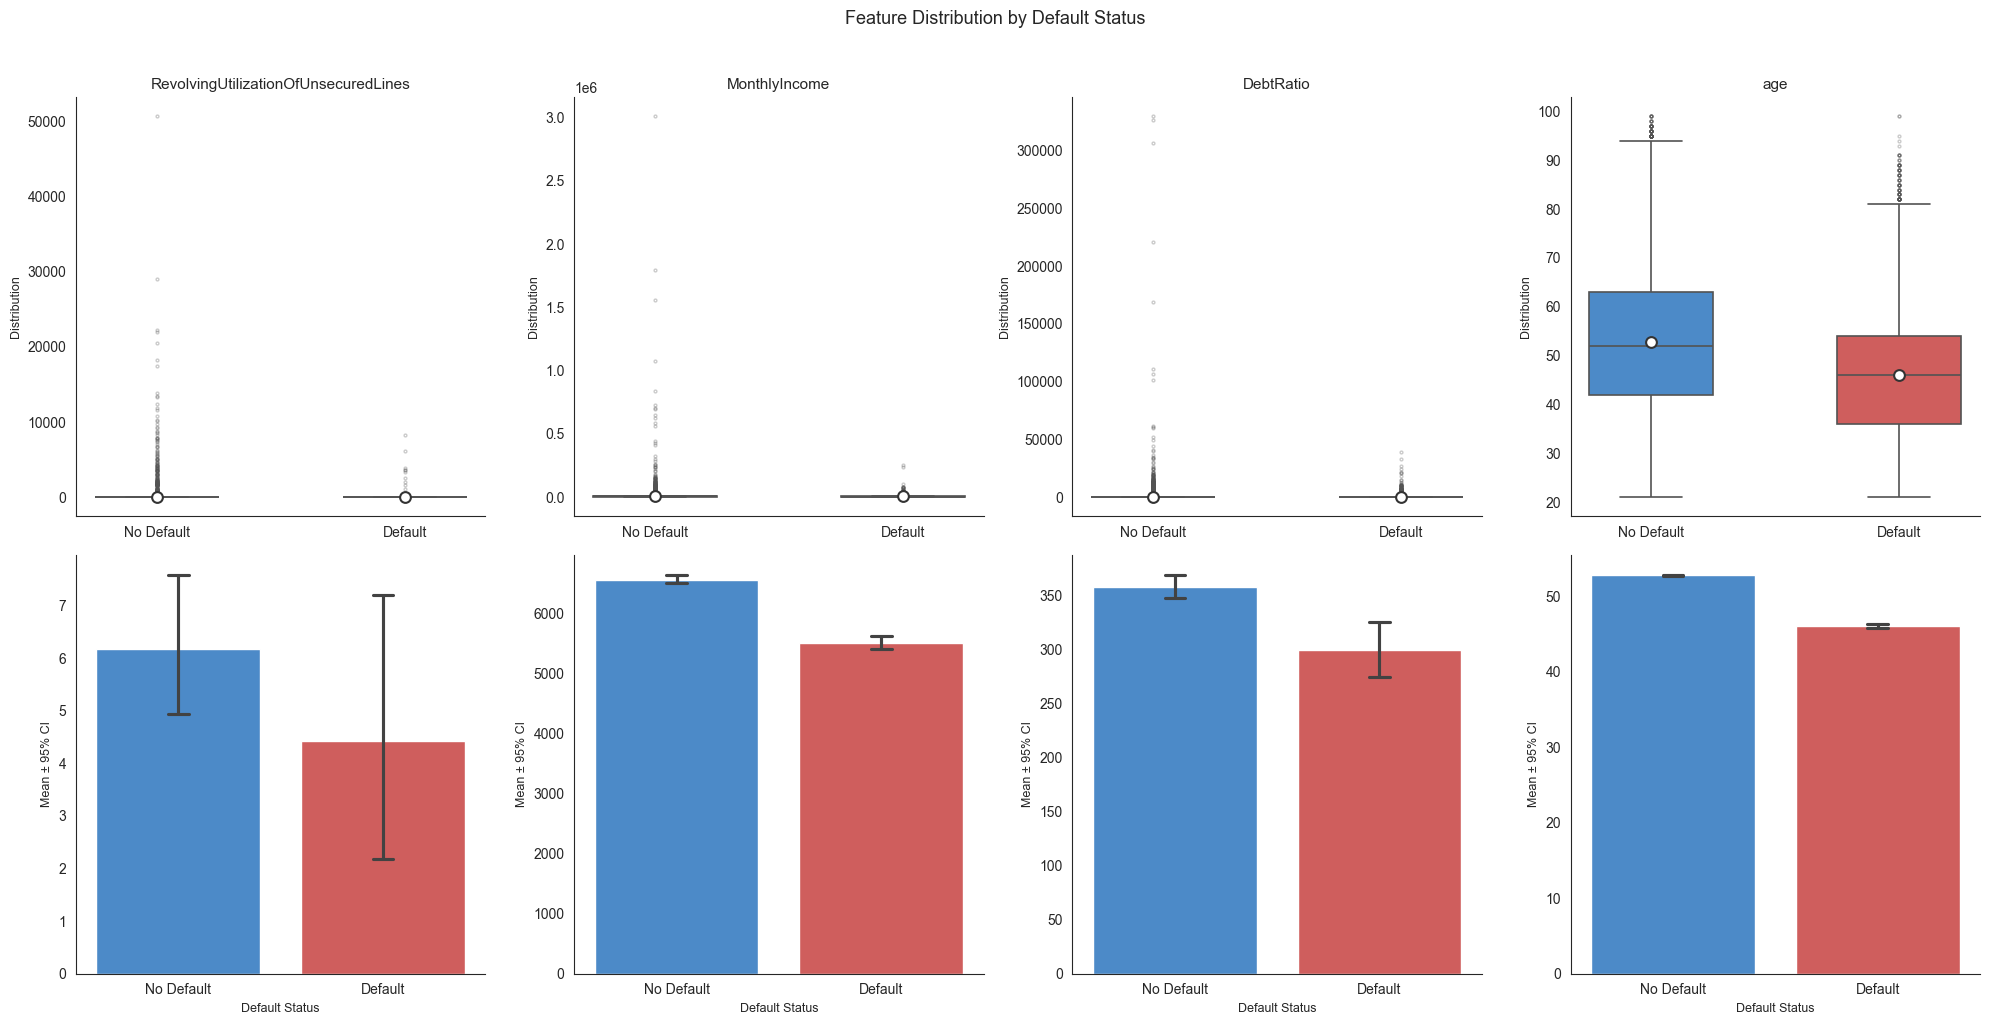

In [63]:
def plot_feature_distribution_by_default(df, features, target="SeriousDlqin2yrs", figsize=(20, 10)):
    """
    Compare feature distributions between default and non-default groups
    using boxplots (distribution) and barplots (mean comparison).
    """

    fig, axes = plt.subplots(2, len(features), figsize=figsize)

    for i, feat in enumerate(features):

        # =====================================================
        # Top row: Boxplot (distribution view)
        # =====================================================
        ax_box = axes[0, i]

        sns.boxplot(
            data=df,
            x=target,
            y=feat,
            palette={"0": "#378ADD", "1": "#E24B4A"},
            width=0.5,
            linewidth=1.2,
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=ax_box
        )

        # Add mean points
        means = df.groupby(target)[feat].mean()
        ax_box.scatter(
            means.index,
            means.values,
            color="white",
            edgecolors="#333",
            s=60,
            linewidths=1.5,
            zorder=5
        )

        ax_box.set_title(feat, fontsize=11)
        ax_box.set_xlabel("")
        ax_box.set_ylabel("Distribution", fontsize=9)
        ax_box.set_xticklabels(["No Default", "Default"])
        sns.despine(ax=ax_box)

        # =====================================================
        # Bottom row: Barplot (mean comparison)
        # =====================================================
        ax_bar = axes[1, i]

        sns.barplot(
            data=df,
            x=target,
            y=feat,
            palette={"0": "#378ADD", "1": "#E24B4A"},
            capsize=0.1,
            errorbar=('ci', 95),
            ax=ax_bar
        )

        ax_bar.set_xlabel("Default Status", fontsize=9)
        ax_bar.set_ylabel("Mean ± 95% CI", fontsize=9)
        ax_bar.set_xticklabels(["No Default", "Default"])
        sns.despine(ax=ax_bar)

    # =========================================================
    # Global title and layout
    # =========================================================
    plt.suptitle("Feature Distribution by Default Status", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Run
features = ["RevolvingUtilizationOfUnsecuredLines", "MonthlyIncome", "DebtRatio", "age"]
plot_feature_distribution_by_default(df_clean, features)

The boxplots (top row) reveal **extreme outliers** in `RevolvingUtilizationOfUnsecuredLines`, `MonthlyIncome`, and `DebtRatio`, suggesting heavily skewed distributions that may require transformation before modeling. In contrast, `age` displays a more symmetric and interpretable spread. The mean ± 95% CI bar charts (bottom row) highlight statistically significant differences between groups: **non-defaulters** show higher revolving utilization (~6.1 vs ~4.5), higher monthly income (~6,500 vs ~5,400), higher debt ratio (~355 vs ~300), and older age (~52 vs ~46) compared to **defaulters**. This suggests that default risk is not driven by a single factor, but rather emerges from the interplay between credit usage, income level, and borrower age.

## 🧩 Delinquency Impact Analysis

In this subsection, we focus on how different types of past-due behavior relate to credit default risk. We examine both the frequency of delinquency events and how the probability of default changes as the number of late payments increases. This provides a clearer view of whether risk is driven by occasional delays or by repeated patterns of financial distress.

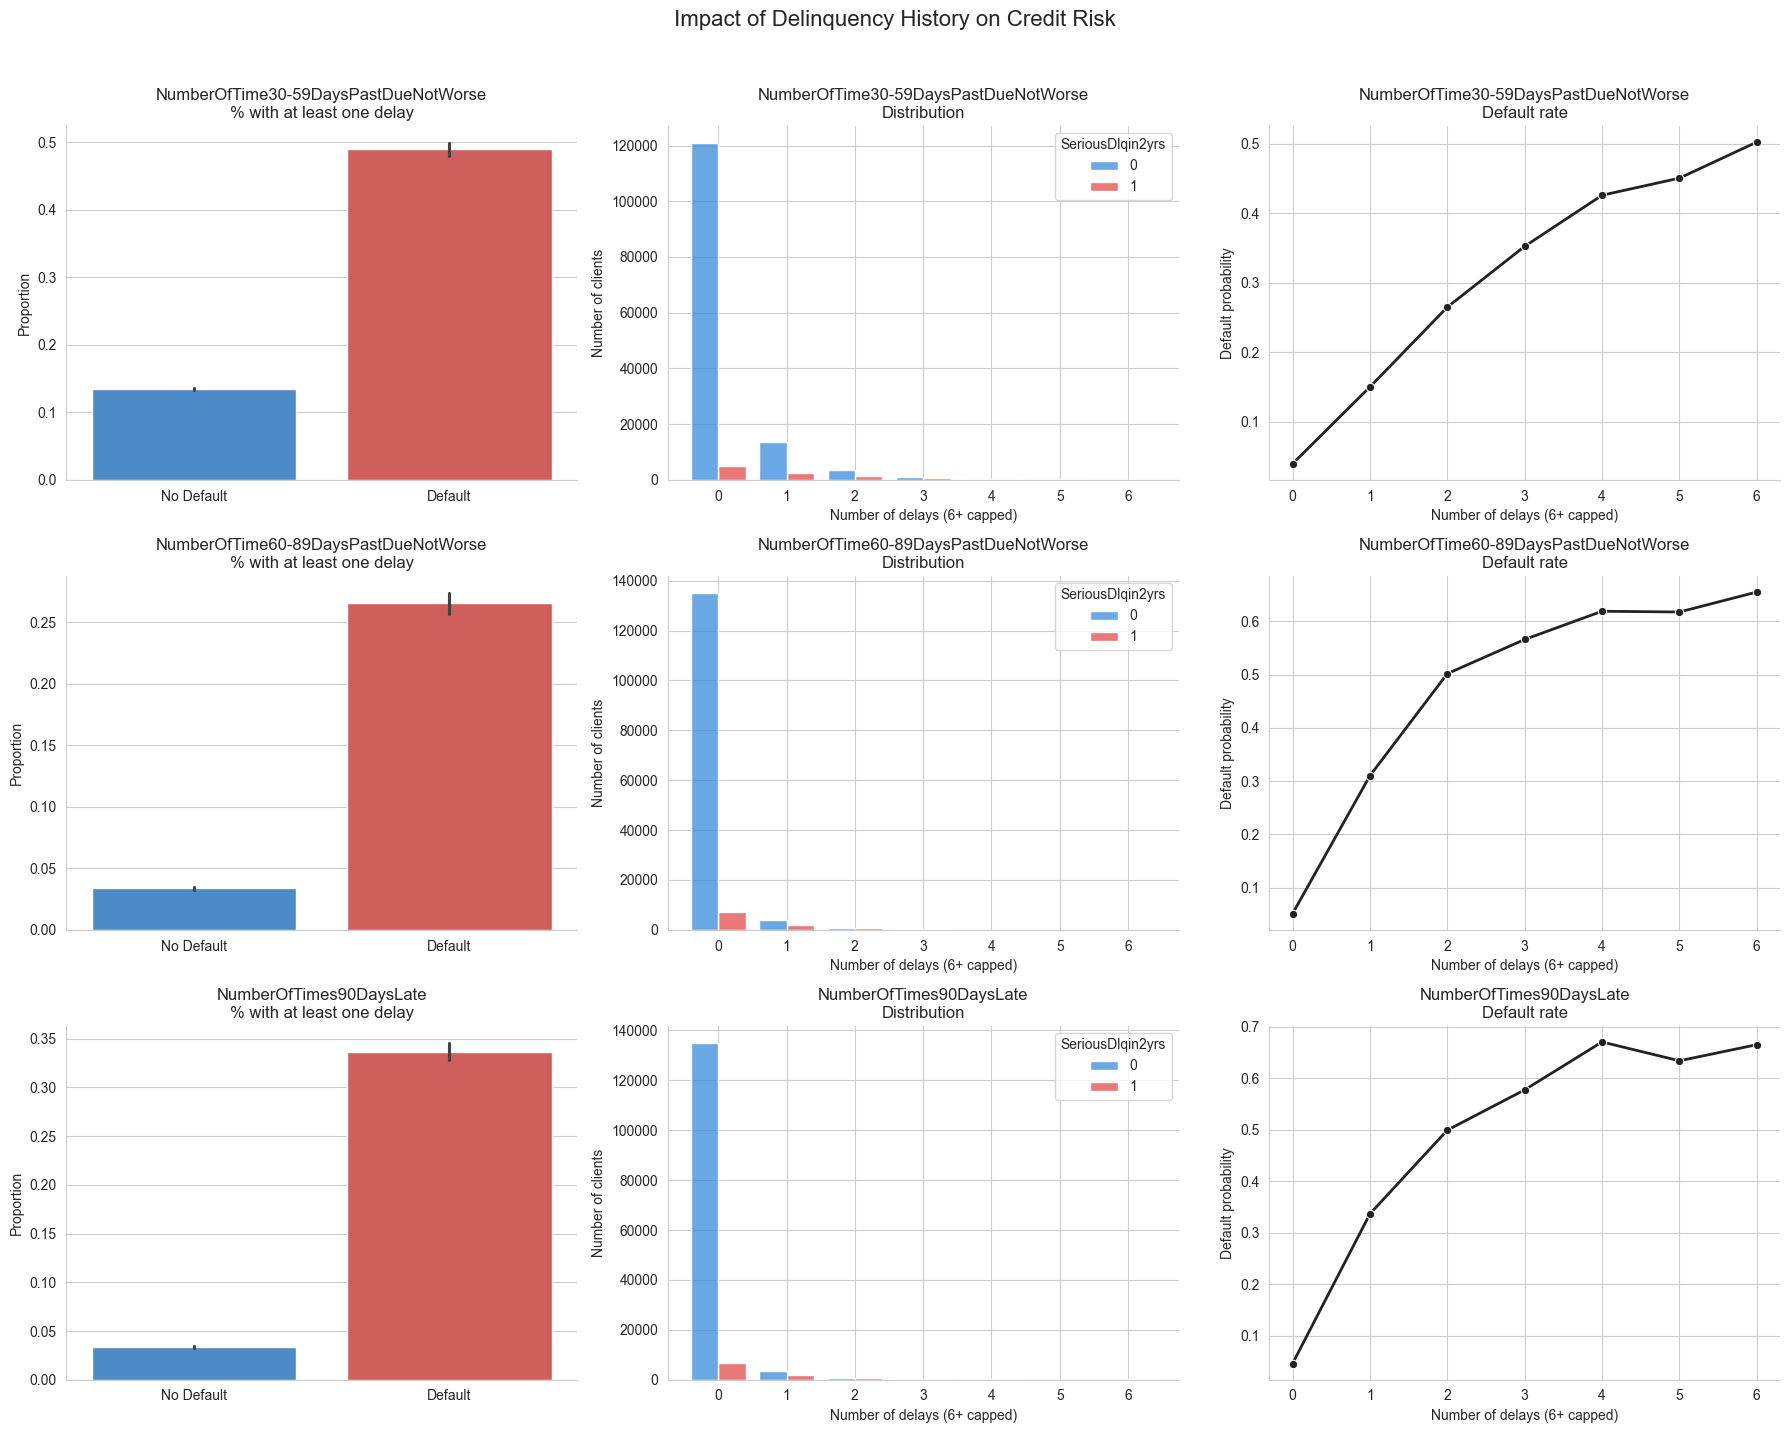

In [64]:
def plot_delinquency_impact(df, features, target="SeriousDlqin2yrs", clip_upper=6, figsize=(18, 14)):
    """
    Analyze impact of delinquency history on credit default risk.

    For each delinquency feature, the function plots:
    1. % of clients with at least one delay
    2. Distribution of delay counts (capped)
    3. Default rate by number of delays
    """

    sns.set_style("whitegrid")

    fig, axes = plt.subplots(len(features), 3, figsize=figsize)

    for i, feat in enumerate(features):

        # =====================================================
        # 1. Percentage of clients with at least one delay
        # =====================================================
        temp_flag = df.copy()
        temp_flag["has_delay"] = (temp_flag[feat] > 0).astype(int)

        sns.barplot(
            data=temp_flag,
            x=target,
            y="has_delay",
            estimator=np.mean,
            errorbar=('ci', 95),
            palette=["#378ADD", "#E24B4A"],
            ax=axes[i, 0]
        )

        axes[i, 0].set_title(f"{feat}\n% with at least one delay")
        axes[i, 0].set_xticklabels(["No Default", "Default"])
        axes[i, 0].set_ylabel("Proportion")
        axes[i, 0].set_xlabel("")

        # =====================================================
        # 2. Distribution of delinquency counts
        # =====================================================
        temp_hist = df.copy()
        temp_hist[feat] = temp_hist[feat].clip(upper=clip_upper)

        sns.histplot(
            data=temp_hist,
            x=feat,
            hue=target,
            multiple="dodge",
            discrete=True,
            shrink=0.8,
            palette=["#378ADD", "#E24B4A"],
            ax=axes[i, 1]
        )

        axes[i, 1].set_title(f"{feat}\nDistribution")
        axes[i, 1].set_xlabel("Number of delays (6+ capped)")
        axes[i, 1].set_ylabel("Number of clients")

        # =====================================================
        # 3. Default rate by number of delays
        # =====================================================
        temp_rate = df.copy()
        temp_rate[feat] = temp_rate[feat].clip(upper=clip_upper)

        risk_curve = (
            temp_rate.groupby(feat)[target]
            .mean()
            .reset_index()
        )

        sns.lineplot(
            data=risk_curve,
            x=feat,
            y=target,
            marker="o",
            linewidth=2,
            color="#222",
            ax=axes[i, 2]
        )

        axes[i, 2].set_title(f"{feat}\nDefault rate")
        axes[i, 2].set_xlabel("Number of delays (6+ capped)")
        axes[i, 2].set_ylabel("Default probability")

    # =========================================================
    # Clean layout
    # =========================================================
    for ax_row in axes:
        for ax in ax_row:
            sns.despine(ax=ax)

    plt.suptitle(
        "Impact of Delinquency History on Credit Risk",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# Run
features = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

plot_delinquency_impact(df_clean, features)

The analysis of delinquency history shows a clear and consistent relationship between past payment issues and future default risk. Across all three delinquency variables (`30-59`, `60-89`, and `90+ days past due`), defaulters exhibit a substantially higher proportion of previous late payments compared to non-defaulters.  

The default rate increases sharply as the number of past due events grows, revealing a strong monotonic risk pattern. Customers with multiple delinquencies present dramatically higher default probabilities, especially for severe late-payment categories (`90+ days late`), where the default rate exceeds 60% for highly delinquent borrowers.  

These results reinforce the importance of repayment behavior as one of the strongest predictors in credit risk modeling and justify the high predictive power observed for delinquency-related features throughout the correlation and feature importance analyses.

### Statistical hypothesis testing

In this subsection, we perform a comparative statistical analysis of key financial and demographic variables across the two target groups defined by the binary outcome variable *SeriousDlqin2yrs*. The objective is to determine whether statistically significant differences exist between defaulters and non-defaulters, as well as to quantify the magnitude of these differences.

Given the characteristics of the data, we first assess distributional assumptions using the Shapiro–Wilk test for normality and Levene’s test for homogeneity of variances. Since financial variables are often skewed and may violate parametric assumptions, we primarily rely on the non-parametric Mann–Whitney U test to evaluate differences between groups.

In addition to statistical significance, we compute Cliff’s Delta as a robust measure of effect size, together with an interpretation of its magnitude. This allows us to complement hypothesis testing with an assessment of practical relevance, providing a more complete understanding of the differences between groups.

In [65]:
import numpy as np
import pingouin as pg
from scipy import stats

def interpret_cliff(d):
    d = abs(d)
    if d < 0.147:   return "negligible"
    elif d < 0.330: return "pequeño"
    elif d < 0.474: return "mediano"
    else:           return "grande"

def interpret_levene(p):
    return "varianzas distintas ⚠️" if p < 0.05 else "varianzas iguales ✓"

features = ["RevolvingUtilizationOfUnsecuredLines", "MonthlyIncome", "DebtRatio", "age"]

results = []

for feat in features:
    g0 = df_clean.loc[df_clean["SeriousDlqin2yrs"] == 0, feat].dropna()
    g1 = df_clean.loc[df_clean["SeriousDlqin2yrs"] == 1, feat].dropna()

    # Shapiro-Wilk (muestra máx 5000 por limitación del test)
    _, p_shap0 = stats.shapiro(g0.sample(min(5000, len(g0)), random_state=42))
    _, p_shap1 = stats.shapiro(g1.sample(min(5000, len(g1)), random_state=42))

    # Levene
    _, p_lev = stats.levene(g0, g1)

    # Mann-Whitney U (no paramétrico, apropiado dado que Shapiro fallará)
    u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')

    # Cliff's Delta
    d = pg.compute_effsize(g1, g0, eftype='CLES')

    results.append({
        "Variable":       feat,
        "Shapiro p (0)":  round(p_shap0, 4),
        "Shapiro p (1)":  round(p_shap1, 4),
        "Normalidad":     "no normal ✗" if (p_shap0 < 0.05 or p_shap1 < 0.05) else "normal ✓",
        "Levene p":       round(p_lev, 4),
        "Varianzas":      interpret_levene(p_lev),
        "Mann-Whitney p": round(p_mw, 6),
        "Sig. diferencia":  "sí ✓" if p_mw < 0.05 else "no ✗",
        "Cliff's Delta":  round(d, 3),
        "Tamaño efecto":  interpret_cliff(d),
    })

df_results = pd.DataFrame(results).set_index("Variable")
print(df_results.T.to_string())

Variable        RevolvingUtilizationOfUnsecuredLines           MonthlyIncome               DebtRatio                     age
Shapiro p (0)                                    0.0                     0.0                     0.0                     0.0
Shapiro p (1)                                    0.0                     0.0                     0.0                     0.0
Normalidad                               no normal ✗             no normal ✗             no normal ✗             no normal ✗
Levene p                                      0.4195                  0.0039                  0.0062                     0.0
Varianzas                        varianzas iguales ✓  varianzas distintas ⚠️  varianzas distintas ⚠️  varianzas distintas ⚠️
Mann-Whitney p                                   0.0                     0.0                     0.0                     0.0
Sig. diferencia                                 sí ✓                    sí ✓                    sí ✓                    sí ✓


The statistical analysis confirms that the distributions of key financial variables differ significantly between defaulters and non-defaulters. Since all variables failed the Shapiro-Wilk normality test, non-parametric methods were prioritized for group comparison. The Mann-Whitney U test indicates statistically significant differences across all analyzed features (*p* < 0.001), while Levene’s test suggests heterogeneous variances for variables such as `DebtRatio` and `age`.

Effect size analysis using Cliff’s Delta reveals especially strong separation for `RevolvingUtilizationOfUnsecuredLines` (Δ = 0.776) and `DebtRatio` (Δ = 0.529), both showing large practical effects. This suggests that high credit utilization and leverage are strongly associated with default behavior. In contrast, `age` presents a moderate effect size (Δ = 0.366), indicating that although age contributes to risk differentiation, its impact is less pronounced than financial exposure variables.

## Age-Based Risk Behavior Analysis

To understand how credit risk varies across different life stages, we analyze default occurrences and delinquency patterns by age. This visualization helps identify whether certain age groups are more prone to financial distress, both in terms of outright default and repeated late payments. By breaking down delinquency into different severity levels, we can better capture how repayment behavior evolves across the age spectrum.

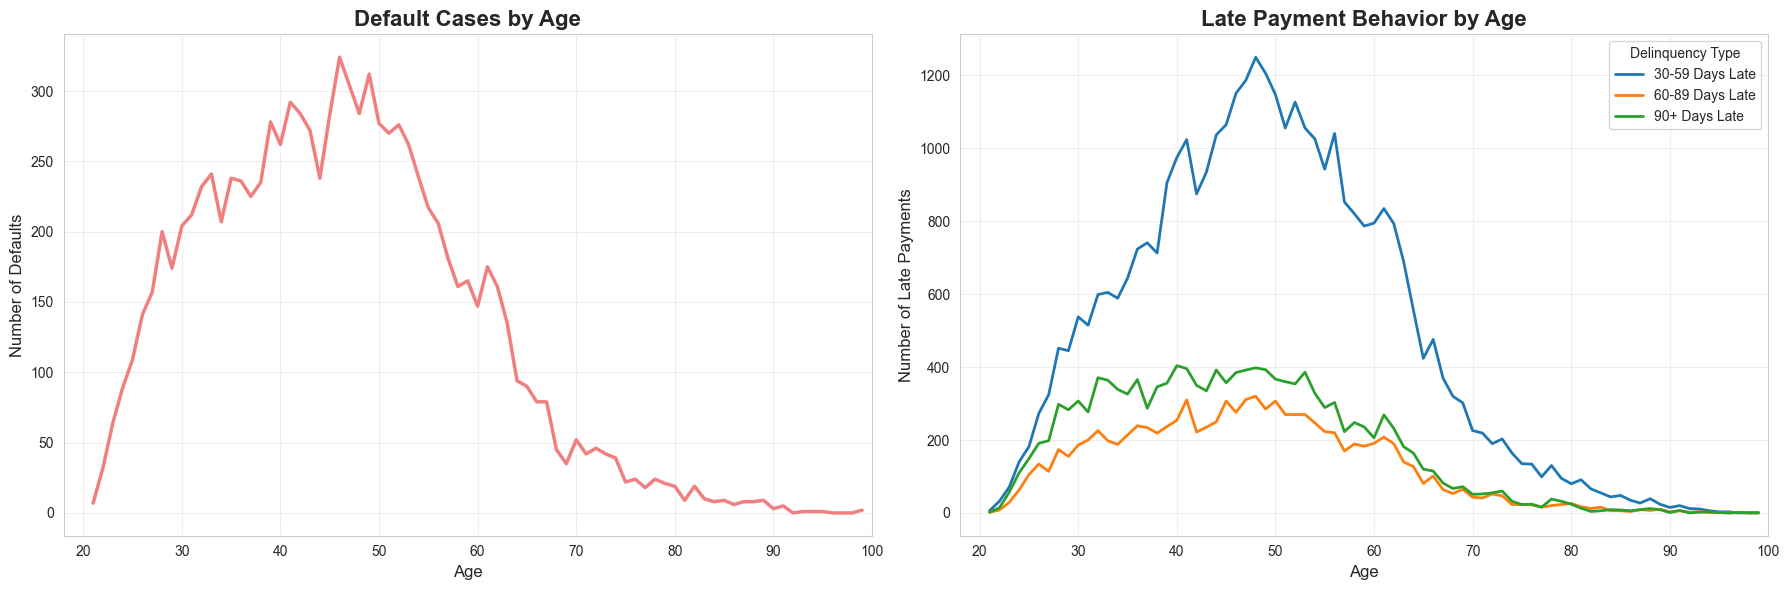

In [66]:
def plot_age_risk_analysis(df, figsize=(18, 6)):
    """
    Visualize credit default behavior and late payment patterns by age.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing age, default target,
        and delinquency-related variables.

    figsize : tuple, default=(18, 6)
        Figure size for the combined plots.
    """

    # Create figure with two side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # =========================================================
    # 1. Default Rate by Age
    # =========================================================
    age_default = (
        df.groupby('age')['SeriousDlqin2yrs']
        .sum()
        .reset_index()
    )

    sns.lineplot(
        data=age_default,
        x='age',
        y='SeriousDlqin2yrs',
        color='lightcoral',
        linewidth=2.5,
        ax=axes[0]
    )

    axes[0].set_title(
        'Default Cases by Age',
        fontsize=16,
        fontweight='bold'
    )

    axes[0].set_xlabel('Age', fontsize=12)
    axes[0].set_ylabel('Number of Defaults', fontsize=12)
    axes[0].set_xlim(18, 100)
    axes[0].grid(alpha=0.3)

    # =========================================================
    # 2. Delinquency Patterns by Age
    # =========================================================
    delinquency_features = {
        '30-59 Days Late': 'NumberOfTime30-59DaysPastDueNotWorse',
        '60-89 Days Late': 'NumberOfTime60-89DaysPastDueNotWorse',
        '90+ Days Late': 'NumberOfTimes90DaysLate'
    }

    for label, feature in delinquency_features.items():

        temp_df = (
            df.groupby('age')[feature]
            .sum()
            .reset_index()
        )

        sns.lineplot(
            data=temp_df,
            x='age',
            y=feature,
            label=label,
            linewidth=2,
            ax=axes[1]
        )

    axes[1].set_title(
        'Late Payment Behavior by Age',
        fontsize=16,
        fontweight='bold'
    )

    axes[1].set_xlabel('Age', fontsize=12)
    axes[1].set_ylabel('Number of Late Payments', fontsize=12)
    axes[1].set_xlim(18, 100)
    axes[1].legend(title='Delinquency Type')
    axes[1].grid(alpha=0.3)

    # Final layout
    plt.tight_layout()
    plt.show()


# Run analysis
plot_age_risk_analysis(df_clean)

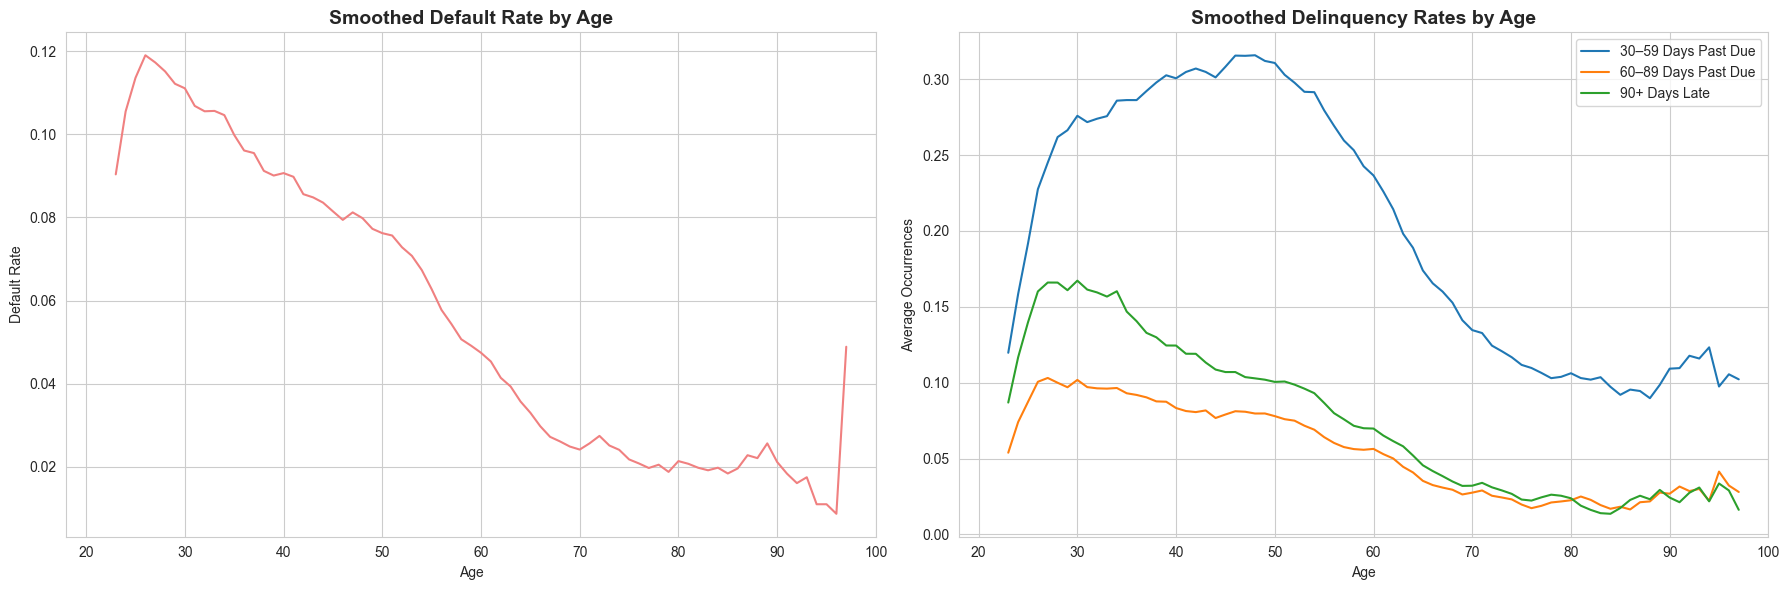

In [67]:
def plot_delinquency_by_age_enhanced(df, age_col="age", window=5):
    """
    Plot smoothed default rate and normalized delinquency rates by age.

    Parameters:
        df (pd.DataFrame): Input dataset
        age_col (str): Age column name
        window (int): Rolling window size for smoothing
    """

    # --- Aggregate data ---
    agg_df = df.groupby(age_col).agg({
        "SeriousDlqin2yrs": "mean",   # default rate
        "NumberOfTime30-59DaysPastDueNotWorse": "mean",
        "NumberOfTime60-89DaysPastDueNotWorse": "mean",
        "NumberOfTimes90DaysLate": "mean"
    }).reset_index()

    # --- Apply smoothing ---
    agg_df["default_rate_smooth"] = agg_df["SeriousDlqin2yrs"].rolling(window, center=True).mean()
    agg_df["late_30_59_smooth"] = agg_df["NumberOfTime30-59DaysPastDueNotWorse"].rolling(window, center=True).mean()
    agg_df["late_60_89_smooth"] = agg_df["NumberOfTime60-89DaysPastDueNotWorse"].rolling(window, center=True).mean()
    agg_df["late_90_smooth"] = agg_df["NumberOfTimes90DaysLate"].rolling(window, center=True).mean()

    # --- Plot setup ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.set_style("whitegrid")

    # --- Plot 1: Smoothed default rate ---
    sns.lineplot(
        x=age_col,
        y="default_rate_smooth",
        data=agg_df,
        ax=axes[0], 
        color = "lightcoral"
    )

    axes[0].set_title("Smoothed Default Rate by Age", fontsize=14, fontweight="bold")
    axes[0].set_xlim(18, 100)
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Default Rate")

    # --- Plot 2: Smoothed delinquency rates ---
    sns.lineplot(
        x=age_col,
        y="late_30_59_smooth",
        data=agg_df,
        label="30–59 Days Past Due",
        ax=axes[1]
    )

    sns.lineplot(
        x=age_col,
        y="late_60_89_smooth",
        data=agg_df,
        label="60–89 Days Past Due",
        ax=axes[1]
    )

    sns.lineplot(
        x=age_col,
        y="late_90_smooth",
        data=agg_df,
        label="90+ Days Late",
        ax=axes[1]
    )

    axes[1].set_title("Smoothed Delinquency Rates by Age", fontsize=14, fontweight="bold")
    axes[1].set_xlim(18, 100)
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("Average Occurrences")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_delinquency_by_age_enhanced(df_clean)

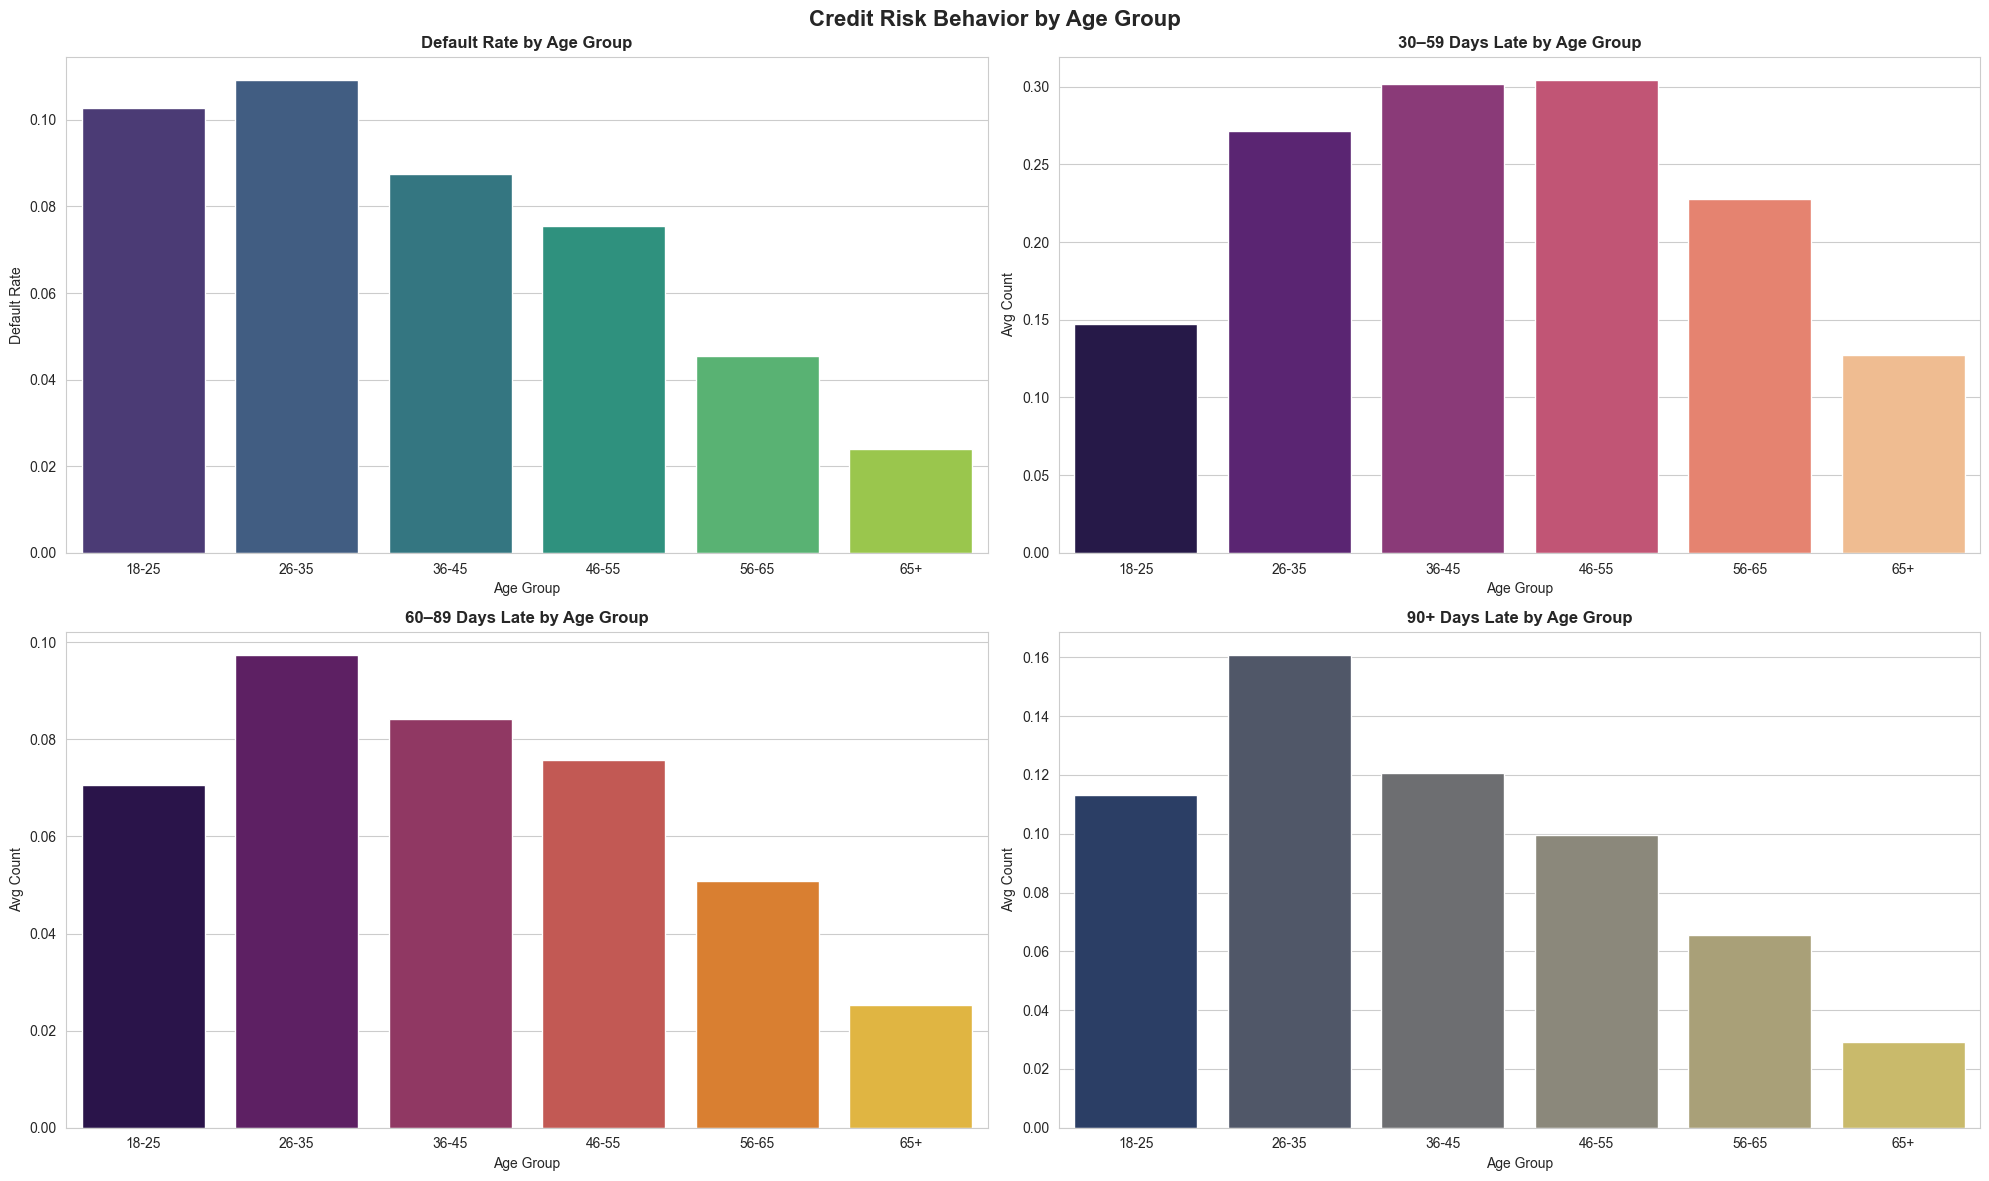

In [68]:
def plot_age_group_risk_analysis(df, figsize=(20, 12)):
    """
    Visualize default and delinquency behavior by age group.

    This function plots:
    - Default rate per age group
    - Average delinquency intensity across different overdue buckets
    """

    # =========================================================
    # Aggregate metrics (use MEAN instead of SUM for comparability)
    # =========================================================
    age_group_df = df.groupby('AgeGroup')['SeriousDlqin2yrs'].mean().reset_index()

    late_30_59 = df.groupby('AgeGroup')['NumberOfTime30-59DaysPastDueNotWorse'].mean().reset_index()
    late_60_89 = df.groupby('AgeGroup')['NumberOfTime60-89DaysPastDueNotWorse'].mean().reset_index()
    late_90 = df.groupby('AgeGroup')['NumberOfTimes90DaysLate'].mean().reset_index()

    # =========================================================
    # Plot setup
    # =========================================================
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # --- Default rate ---
    sns.barplot(
        data=age_group_df,
        x='AgeGroup',
        y='SeriousDlqin2yrs',
        palette='viridis',
        ax=axes[0, 0]
    )
    axes[0, 0].set_title('Default Rate by Age Group', fontweight='bold')
    axes[0, 0].set_xlabel('Age Group')
    axes[0, 0].set_ylabel('Default Rate')

    # --- 30–59 days late ---
    sns.barplot(
        data=late_30_59,
        x='AgeGroup',
        y='NumberOfTime30-59DaysPastDueNotWorse',
        palette='magma',
        ax=axes[0, 1]
    )
    axes[0, 1].set_title('30–59 Days Late by Age Group', fontweight='bold')
    axes[0, 1].set_xlabel('Age Group')
    axes[0, 1].set_ylabel('Avg Count')

    # --- 60–89 days late ---
    sns.barplot(
        data=late_60_89,
        x='AgeGroup',
        y='NumberOfTime60-89DaysPastDueNotWorse',
        palette='inferno',
        ax=axes[1, 0]
    )
    axes[1, 0].set_title('60–89 Days Late by Age Group', fontweight='bold')
    axes[1, 0].set_xlabel('Age Group')
    axes[1, 0].set_ylabel('Avg Count')

    # --- 90+ days late ---
    sns.barplot(
        data=late_90,
        x='AgeGroup',
        y='NumberOfTimes90DaysLate',
        palette='cividis',
        ax=axes[1, 1]
    )
    axes[1, 1].set_title('90+ Days Late by Age Group', fontweight='bold')
    axes[1, 1].set_xlabel('Age Group')
    axes[1, 1].set_ylabel('Avg Count')

    plt.suptitle('Credit Risk Behavior by Age Group', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Run
plot_age_group_risk_analysis(df_clean)

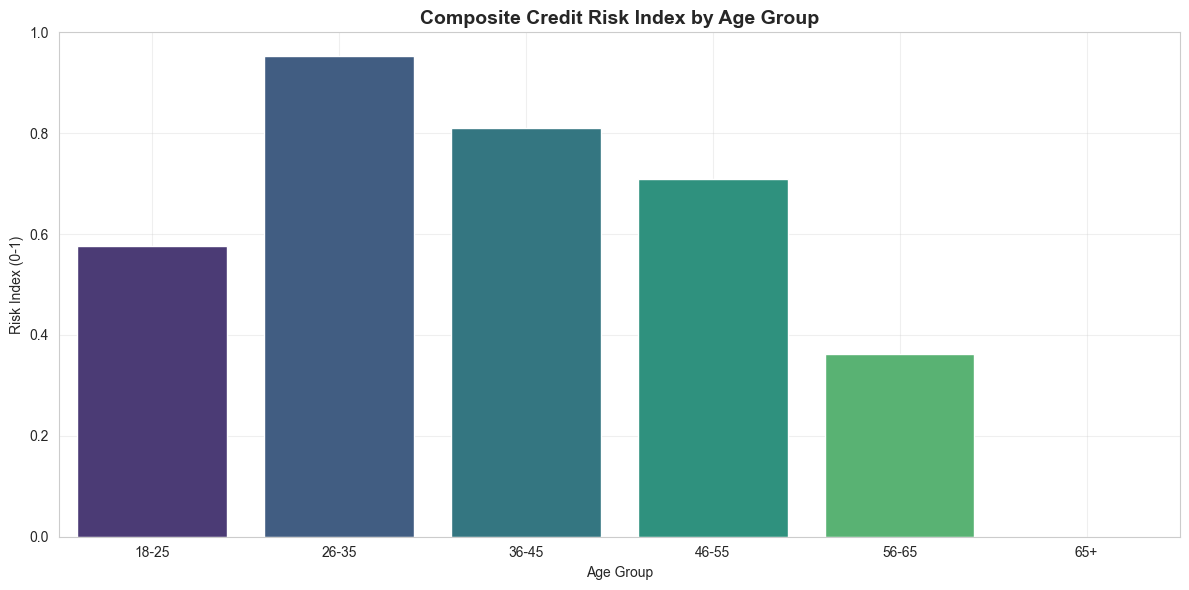

In [69]:
def plot_age_group_risk_index(df, figsize=(12, 6)):
    """
    Create a composite risk index by age group combining:
    - Default rate
    - Delinquency rates

    All metrics are normalized to make them comparable.
    """

    # ---------------------------------------------------------
    # Aggregate by AgeGroup (use mean for comparability)
    # ---------------------------------------------------------
    agg = df.groupby('AgeGroup')[[
        'SeriousDlqin2yrs',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfTimes90DaysLate'
    ]].mean()

    # ---------------------------------------------------------
    # Normalize each feature (0-1 scaling)
    # ---------------------------------------------------------
    normalized = (agg - agg.min()) / (agg.max() - agg.min())

    # ---------------------------------------------------------
    # Risk Index (simple average of signals)
    # ---------------------------------------------------------
    normalized['RiskIndex'] = normalized.mean(axis=1)

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    plt.figure(figsize=figsize)

    sns.barplot(
        x=normalized.index,
        y=normalized['RiskIndex'],
        palette='viridis'
    )

    plt.title('Composite Credit Risk Index by Age Group', fontsize=14, fontweight='bold')
    plt.xlabel('Age Group')
    plt.ylabel('Risk Index (0-1)')
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return normalized

# Run
risk_by_age = plot_age_group_risk_index(df_clean)

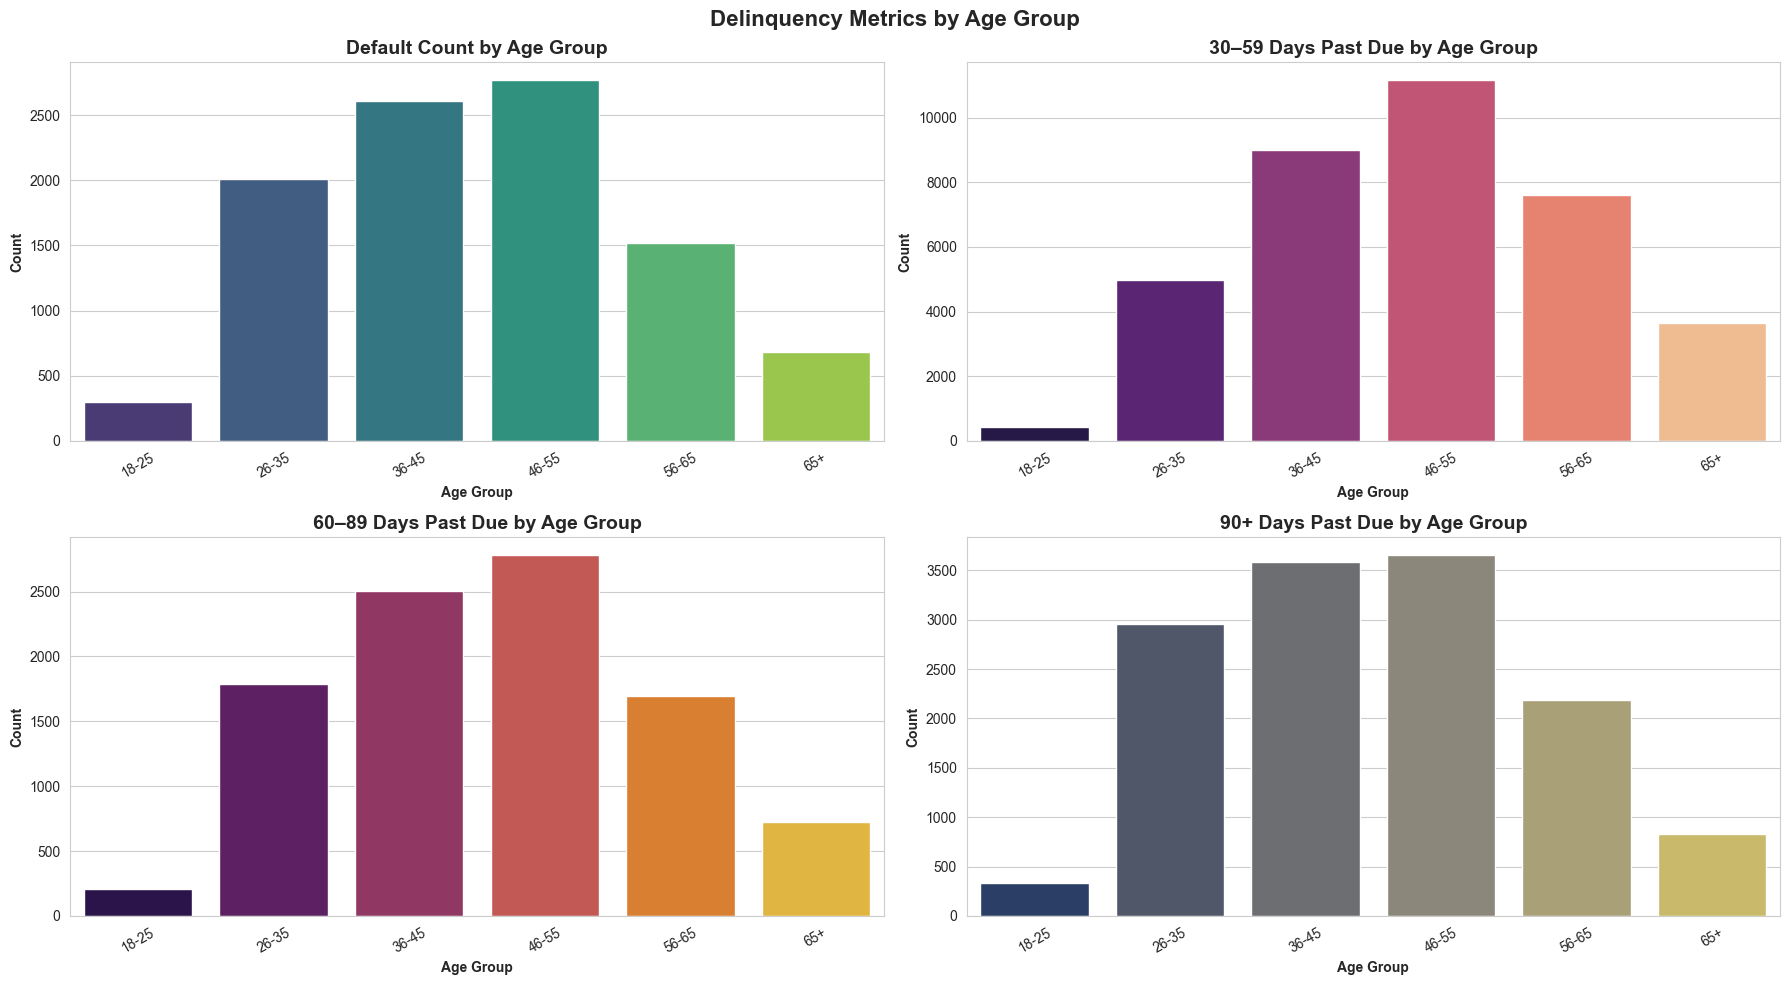

In [70]:
# Delinquency by age

def plot_delinquency_by_age(df, age_col="AgeGroup"):
    """
    Plot delinquency metrics by age group.

    Parameters:
        df (pd.DataFrame): Input dataset
        age_col (str): Age group column name
    """

    # --- Aggregate data in one step ---
    agg_df = df.groupby(age_col).agg({
        "SeriousDlqin2yrs": "sum",
        "NumberOfTime30-59DaysPastDueNotWorse": "sum",
        "NumberOfTime60-89DaysPastDueNotWorse": "sum",
        "NumberOfTimes90DaysLate": "sum"
    }).reset_index()

    # --- Plot setup ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    sns.set_style("whitegrid")

    # --- Plots ---
    sns.barplot(
        x=age_col, y="SeriousDlqin2yrs",
        data=agg_df, palette="viridis", ax=axes[0, 0]
    )

    sns.barplot(
        x=age_col, y="NumberOfTime30-59DaysPastDueNotWorse",
        data=agg_df, palette="magma", ax=axes[0, 1]
    )

    sns.barplot(
        x=age_col, y="NumberOfTime60-89DaysPastDueNotWorse",
        data=agg_df, palette="inferno", ax=axes[1, 0]
    )

    sns.barplot(
        x=age_col, y="NumberOfTimes90DaysLate",
        data=agg_df, palette="cividis", ax=axes[1, 1]
    )

    # --- Titles ---
    axes[0, 0].set_title("Default Count by Age Group", fontsize=14, fontweight="bold")
    axes[0, 1].set_title("30–59 Days Past Due by Age Group", fontsize=14, fontweight="bold")
    axes[1, 0].set_title("60–89 Days Past Due by Age Group", fontsize=14, fontweight="bold")
    axes[1, 1].set_title("90+ Days Past Due by Age Group", fontsize=14, fontweight="bold")

    # --- Formatting ---
    for ax in axes.flat:
        ax.set_xlabel("Age Group", fontweight="bold")
        ax.set_ylabel("Count", fontweight="bold")
        ax.tick_params(axis="x", rotation=30)

    plt.suptitle("Delinquency Metrics by Age Group", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_delinquency_by_age(df_clean)

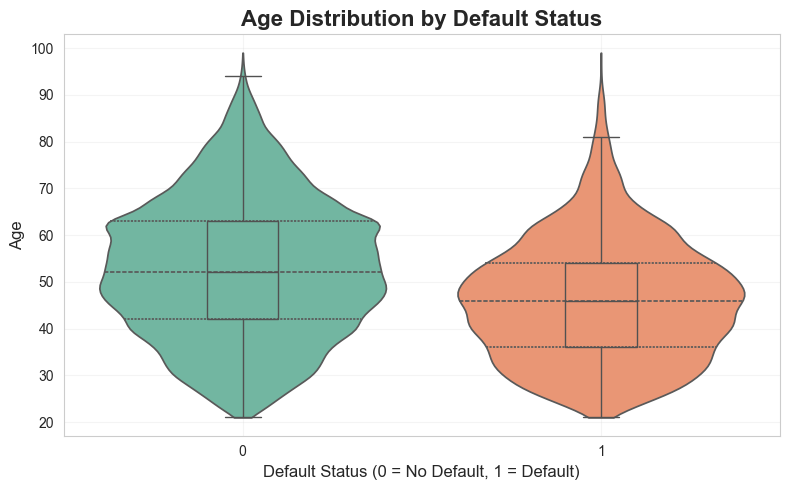

In [71]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    x='SeriousDlqin2yrs',
    y='age',
    data=df_clean,
    palette='Set2',
    inner='quartile',
    cut=0
)

sns.boxplot(
    x='SeriousDlqin2yrs',
    y='age',
    data=df_clean,
    width=0.2,
    showcaps=True,
    boxprops={'facecolor':'none'},
    showfliers=False
)

plt.title('Age Distribution by Default Status', fontsize=16, fontweight='bold')
plt.xlabel('Default Status (0 = No Default, 1 = Default)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Key Insights: Age Analysis**

- Default risk is not strictly decreasing or increasing with age; it shows a non-linear pattern.
- Middle-aged groups tend to concentrate higher delinquency activity across all overdue buckets.
- Older groups show fewer delinquency events, but still retain non-zero default risk.
- Overall, age alone is not a strong predictor, but it becomes more informative when combined with delinquency behavior.